# DAI Mission
**Data & AI in Economics | TU Dortmund**

## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Leila Rahimiyadkuri | |
| Member | Forough Asgari | |
| Member | Sara Davoodabadi | |

## 2. Mission Title & Research Question

**Title:**  
Predicting and Explaining Customer Churn in Telecommunications: Combining Causal Inference, Supervised Classification, and Customer Segmentation

**Research question:**  
Does the type of contract a telecom customer holds (*month-to-month* vs. *longer-term*) causally increase their probability of churning and does this effect differ across distinct customer segments identified through unsupervised learning?

**Why it matters:**  
Telecom companies face high customer turnover, and retaining an existing customer is significantly cheaper than acquiring a new one. Most churn models tell you *who* is likely to leave, but not *why*. We want to separate correlation from causation: if month-to-month contracts genuinely *cause* higher churn (rather than simply being chosen by customers who were already planning to leave), then offering contract upgrades or lock-in incentives becomes a concrete, cost-effective retention lever. That distinction between prediction and causal mechanism is what drives our methodological design.

## 3. Data

Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Unit of observation:** One row = one individual telecom customer. The dataset contains 7,043 rows and 21 columns.

**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| customerID | String | Identifier (excluded) | Unique customer ID - carries no predictive or causal information |
| Churn | Binary (Yes/No) | Target (Y) | Whether the customer left the company (Yes = churned) |
| Contract | Categorical | Treatment (W₁) | Contract type: Month-to-month, One year, Two year - our primary treatment variable |
| MonthlyCharges | Float | Treatment (W₂) | Amount charged to the customer per month |
| tenure | Integer | Confounder (X₁) | Number of months the customer has been with the company - affects both contract choice and churn likelihood |
| SeniorCitizen | Binary (0/1) | Confounder (X₂) | Whether the customer is a senior citizen - affects both spending patterns and loyalty |
| Partner | Binary (Yes/No) | Confounder (X₃) | Whether the customer has a partner - household situation affects contract preferences |
| Dependents | Binary (Yes/No) | Confounder (X₄) | Whether the customer has dependents - family situation affects switching costs |
| InternetService | Categorical | Feature | Type of internet service: DSL, Fiber optic, or None |
| OnlineSecurity | Categorical |  Mediator (excluded from DAG adjustment) | Add-on service - sits between Contract and Churn, conditioning on it would block the causal path |
| TechSupport | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| StreamingTV | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| StreamingMovies | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| OnlineBackup | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| DeviceProtection | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| PhoneService | Binary (Yes/No) | Feature | Whether the customer has phone service |
| MultipleLines | Categorical | Feature | Whether the customer has multiple lines |
| PaperlessBilling | Binary (Yes/No) | Feature | Whether the customer uses paperless billing |
| PaymentMethod | Categorical | Feature | Payment method used by the customer |
| TotalCharges | Float | Feature | Total amount charged over the customer's lifetime - note: stored as string in raw data, requires conversion |

**Data quality & composition - known issues and mitigation plan:**

Even though this is a well-known Kaggle dataset, it has several concrete issues we will address explicitly:

1. **`TotalCharges` stored as string:** The column appears numeric but is of type `object` in the raw CSV, and contains 11 blank strings for customers with `tenure = 0`. We will convert using `pd.to_numeric(..., errors='coerce')` and impute or drop the 11 affected rows (they represent ~0.15% of data).

2. **`No internet service` as a categorical level:** Several add-on columns (e.g. `OnlineSecurity`, `TechSupport`) use `"No internet service"` as a third category instead of simply `"No"`. This is redundant and can confuse models. We will collapse these to binary Yes/No before encoding.

3. **Class imbalance (~26% churn rate):** The dataset is imbalanced - roughly 1 in 4 customers churned. We will not oversample, but will use `class_weight='balanced'` in our classifiers and report AUC-ROC and F1-Score rather than raw accuracy.

4. **Potential collection bias:** This dataset was originally created by IBM for demonstration purposes, not from a real anonymized telco. Features may be cleaner than real-world data, and the churn patterns may not generalize. We will discuss this limitation explicitly.

## 4. Planned Methods

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment

**Justification:** Month-to-month customers churn more, but they also tend to be newer and more price-sensitive characteristics that exist before the contract choice. Comparing raw churn rates by contract type conflates those pre-existing differences with the contract's actual effect. We build a DAG, apply backdoor adjustment conditioning on pre-treatment confounders only, and validate the result with two refutation tests.

### 4b. Supervised Learning
- [x] Logistic Regression
- [x] Random Forest

**Justification:** Churn is binary, so this is a classification task. Logistic Regression gives interpretable log-odds coefficients we can compare to our causal estimates. Random Forest captures non-linear interactions and threshold effects. Both are compared against a dummy majority-class baseline.

### 4c. Unsupervised Learning
- [x] K-Means clustering

**Justification:** The research question has two parts: does contract type causally increase churn, and does this effect differ across segments? K-Means answers the prior question: are there natural customer types with meaningfully different churn dynamics? We then re-run the causal model separately per cluster to answer the second part.

## 5. Evaluation Strategy

**Predictive models:** AUC-ROC is our primary metric. It is robust to class imbalance and summarizes performance across all decision thresholds. We also report PR-AUC, Precision, Recall, F1, and Accuracy. Recall matters here because missing a real churner is more costly than a wasted retention offer. All models are compared to a dummy baseline.

**Causal estimates:** Two refutation tests : random common cause (ATE should remain stable) and placebo treatment (ATE should collapse to near zero). Passing both tests supports the validity of the causal estimate.

**Clustering:** k selected by elbow method and silhouette coefficient jointly. Each cluster is interpreted in business terms. The stratified causal analysis per cluster directly answers the second half of the research question.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | All | Data collection and cleaning |
| 2 | Leila | EDA |
| 3 | Leila | Causal inference block |
| 4 | Sara | Supervised learning block |
| 5 | Forough | Unsupervised block |
| 6 | All | Synthesis and write-up |

---
## 7. Results

### 7a. Data Loading, Cleaning and Exploratory Analysis

In [12]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

# Download Telco dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
Telco = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("Shape:", Telco.shape)
Telco.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### b. First look : types, missing values, churn rate

Before changing anything, we check the column types, missing values, and the churn rate. The churn rate matters immediately because it determines which evaluation metrics are appropriate. With 73% of customers staying, raw accuracy is misleading ; a model that always predicts "stayed" looks 73% accurate but catches zero churners.

In [13]:
# ──  First look at the data ──────────────────────────────

# 1. Column types and missing values
print("=== Column Info ==================")
print(Telco.dtypes)

# 2. Check churn rate
print("\n=== Churn Rate ===============")
print(Telco['Churn'].value_counts())
print(Telco['Churn'].value_counts(normalize=True).round(3) * 100, "%")

# 3. Check for missing values
print("\n=== Missing Values ==============")
print(Telco.isnull().sum())

# 4. Fix 'TotalCharges' (stored as str)
Telco['TotalCharges'] = pd.to_numeric(Telco['TotalCharges'], errors='coerce')
print("\n=== TotalCharges missing after fix ===")
print(Telco['TotalCharges'].isnull().sum())

=== Column Info ==================
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Churn Rate ===============
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %

=== Missing Values ==============
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0

#### c. Clean the data

Four concrete issues to address:
1. `TotalCharges` is stored as a string and has 11 blank entries for brand-new customers. We convert to float and drop those rows.
2. Several add-on columns use `"No internet service"` as a third category instead of `"No"`.
3. `MultipleLines` uses `"No phone service"` similarly.
4. `customerID` carries no information. We drop it.
5. `Churn` needs to be 0/1 for all modeling steps.

In [14]:
# ──  Clean the data ───────────────────────────────────────

# 1. Fix Churn -> 0/1
Telco['Churn'] = Telco['Churn'].map({'Yes': 1, 'No': 0})

# 2. Drop the 11 rows with missing 'TotalCharges'
Telco = Telco.dropna(subset=['TotalCharges'])

# 3. Drop customerID - useless column (id)
Telco = Telco.drop(columns=['customerID'])

# 4. Fix "No internet service" -> "No" 
cols_with_no_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
Telco[cols_with_no_internet] = Telco[cols_with_no_internet].replace(
    'No internet service', 'No'
)

# 5. Fix "No phone service" -> "No"
Telco['MultipleLines'] = Telco['MultipleLines'].replace('No phone service', 'No')

# Check
print("=== Shape after cleaning =============")
print(Telco.shape)

print("\n=== Churn distribution ===============")
print(Telco['Churn'].value_counts())

print("\n=== Sample ===============")
## 3.1 Exploratory Data Analysis (EDA)Telco.head(3)

=== Shape after cleaning =============
(7032, 20)

=== Churn distribution ===============
Churn
0    5163
1    1869
Name: count, dtype: int64

=== Sample ===============


#### d. Target variable : how many customers churned?

We start EDA with the target variable. 26.6% of customers churned. This is why we use AUC-ROC and F1 rather than accuracy throughout.

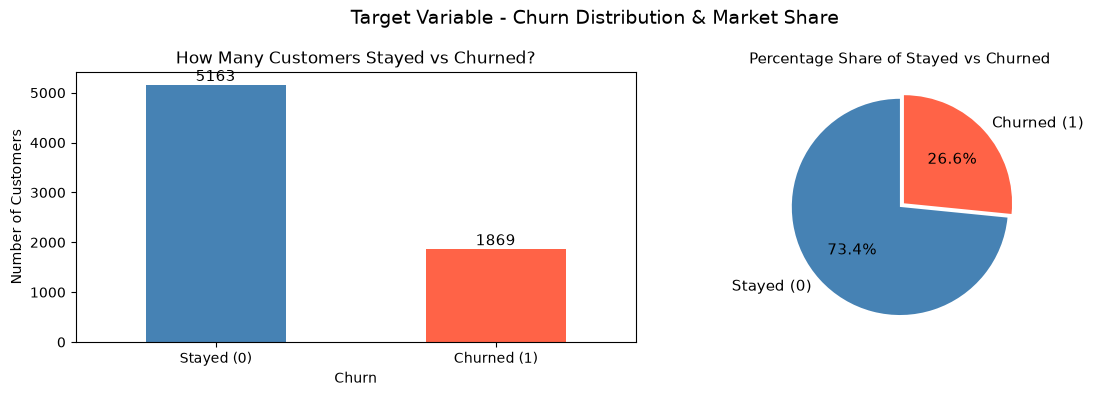

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
Telco['Churn'].value_counts().plot(kind='bar', ax=axes[0],
                                    color=['steelblue', 'tomato'])
axes[0].set_title('How Many Customers Stayed vs Churned?')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Percentage
churn_counts = Telco['Churn'].value_counts()
axes[1].pie(churn_counts, 
            labels=['Stayed (0)', 'Churned (1)'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['steelblue', 'tomato'],
            textprops={'fontsize': 11},
            explode=(0, 0.05)) # 
axes[1].set_title('Percentage Share of Stayed vs Churned', fontsize=11)

plt.suptitle('Target Variable - Churn Distribution & Market Share', fontsize=14)
plt.tight_layout()
plt.savefig('../ResultPics/EDA/churn_distribution.png', bbox_inches='tight')
plt.show()

#### e. Feature importance : which variables are most related to churn?

Before plotting all 20 columns, we rank features by their correlation with Churn. This tells us which variables deserve careful attention in the EDA and confirms which should be treatments, confounders, or features in our models.

C:\Users\Leila\AppData\Local\Temp\ipykernel_20340\1382898468.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in Telco_encoded.select_dtypes(include='object').columns:


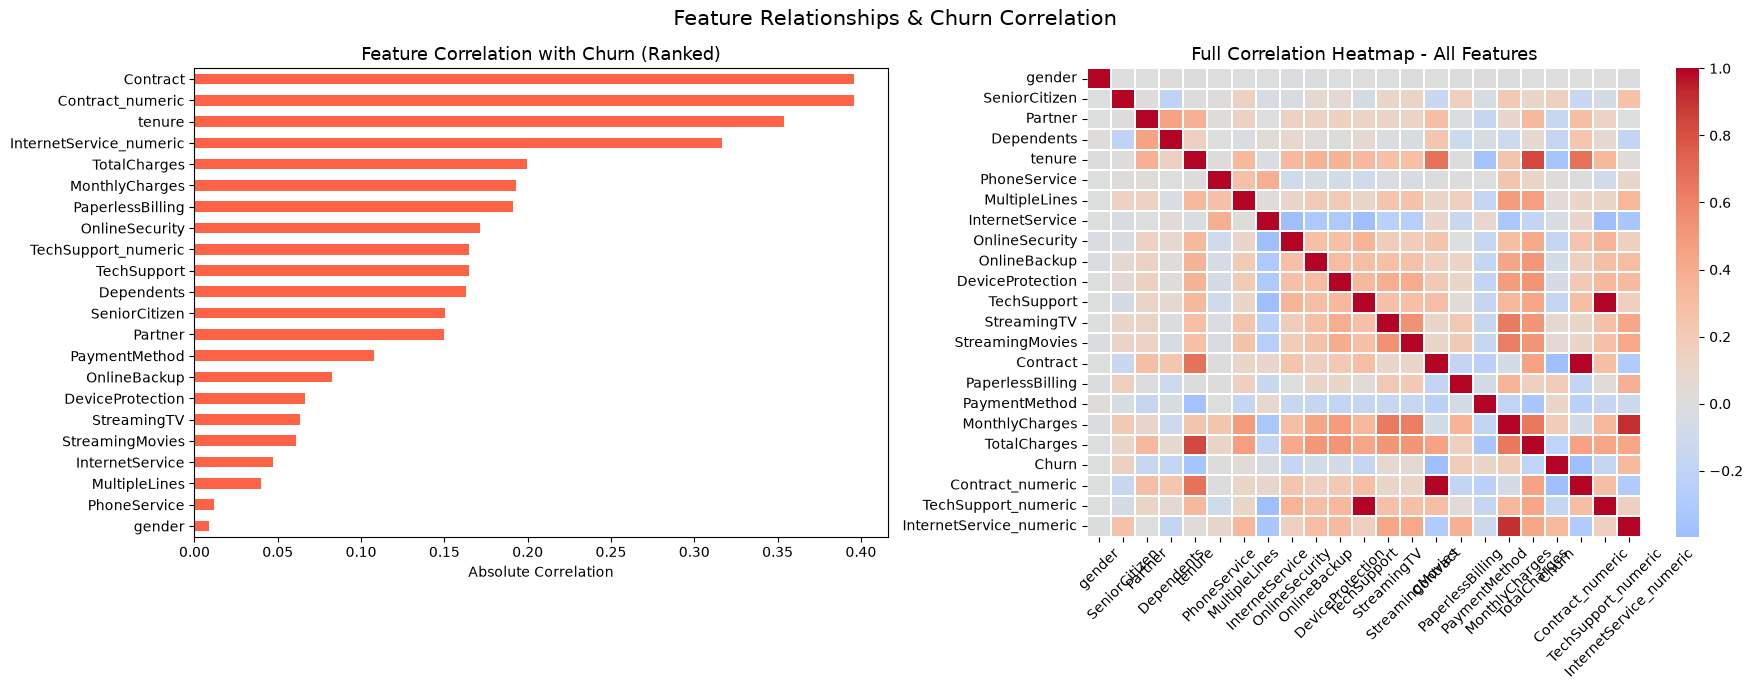

=== Top 4 Features Correlated with Churn =============
Contract                   0.396
Contract_numeric           0.396
tenure                     0.354
InternetService_numeric    0.316
TotalCharges               0.199
Name: Churn, dtype: float64


In [ ]:
# ──  Feature Correlation Heatmap ─────────────────────────────
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


# Encode all categorical columns temporarily
Telco_encoded = Telco.copy()
for col in Telco_encoded.select_dtypes(include='object').columns:
    Telco_encoded[col] = LabelEncoder().fit_transform(Telco_encoded[col])

# Correlation with Churn - ranked bar plot
churn_corr = Telco_encoded.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1 - Ranked bar chart
churn_corr.plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Feature Correlation with Churn (Ranked)', fontsize=13)
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Plot 2 - Full heatmap of all features
full_corr = Telco_encoded.corr()
sns.heatmap(full_corr, 
            annot=False,          # too many features for numbers
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            ax=axes[1])
axes[1].set_title('Full Correlation Heatmap - All Features', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Feature Relationships & Churn Correlation', fontsize=15)
plt.tight_layout()
plt.savefig('../ResultPics/EDA/full_correlation.png', bbox_inches='tight')
plt.show()

print("=== Top 4 Features Correlated with Churn =============")
print(churn_corr.head(5).round(3))

**Key findings:**
- `Contract` is the strongest signal (|r| ≈ 0.40). Confirms it as our primary treatment variable.
- `tenure` is second (|r| ≈ 0.35). New customers both pick short contracts and churn more. Confirms it as a confounder.
- `TotalCharges` correlates with `tenure` at r ≈ 0.83. It is not independent. It is approximately tenure × MonthlyCharges, so we exclude it from the causal DAG.

#### f. Categorical features - stayed vs churned

Each bar shows the percentage breakdown within each category. 100% normalization makes it easy to compare churn rates across groups of very different sizes.

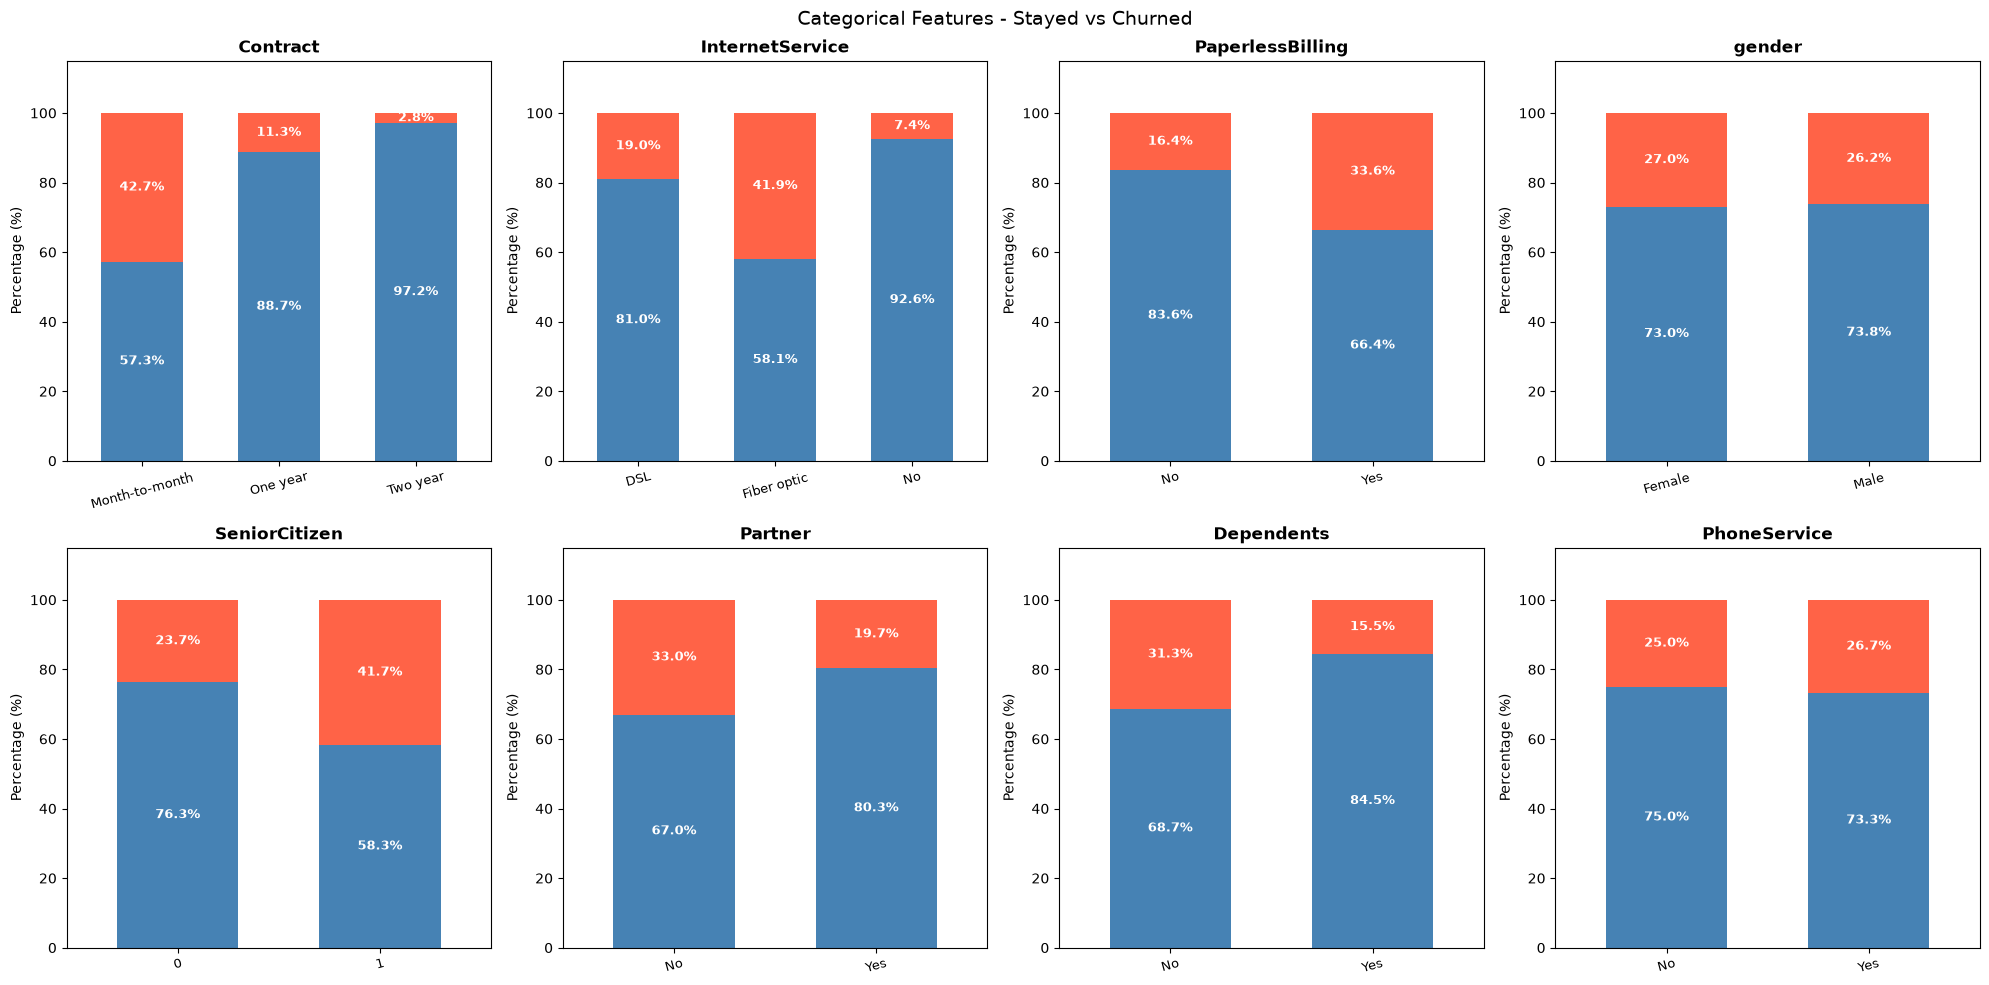

In [41]:
# All categorical features including Contract
cat_cols = ['Contract', 'InternetService', 'PaperlessBilling',
            'gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    # 1. Compute the frequency matrix between the feature and Churn
    crosstab = pd.crosstab(Telco[col], Telco['Churn'])

    # 2. Convert frequencies to percentages so each row sums to 100%
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    # 3. Plot as a stacked bar chart
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[i],
                      color=['steelblue', 'tomato'], width=0.6, legend=False)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 115)  # extra space at top for percentage labels
    axes[i].tick_params(axis='x', rotation=15, labelsize=9)

    # 4. Add percentage labels centered inside each bar segment
    for patch in axes[i].patches:
        width, height = patch.get_width(), patch.get_height()
        x, y = patch.get_xy()
        if height > 0:  # skip zero-height segments
            axes[i].annotate(f'{height:.1f}%',
                             (x + width/2, y + height/2),
                             ha='center', va='center',
                             color='white', fontsize=9, fontweight='bold')

plt.suptitle('Categorical Features - Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../ResultPics/EDA/categorical_churn.png', bbox_inches='tight')
plt.show()

#### g. Continuous features - distribution by churn status

Histograms show where churners and stayers are concentrated. Boxplots show the median and spread.

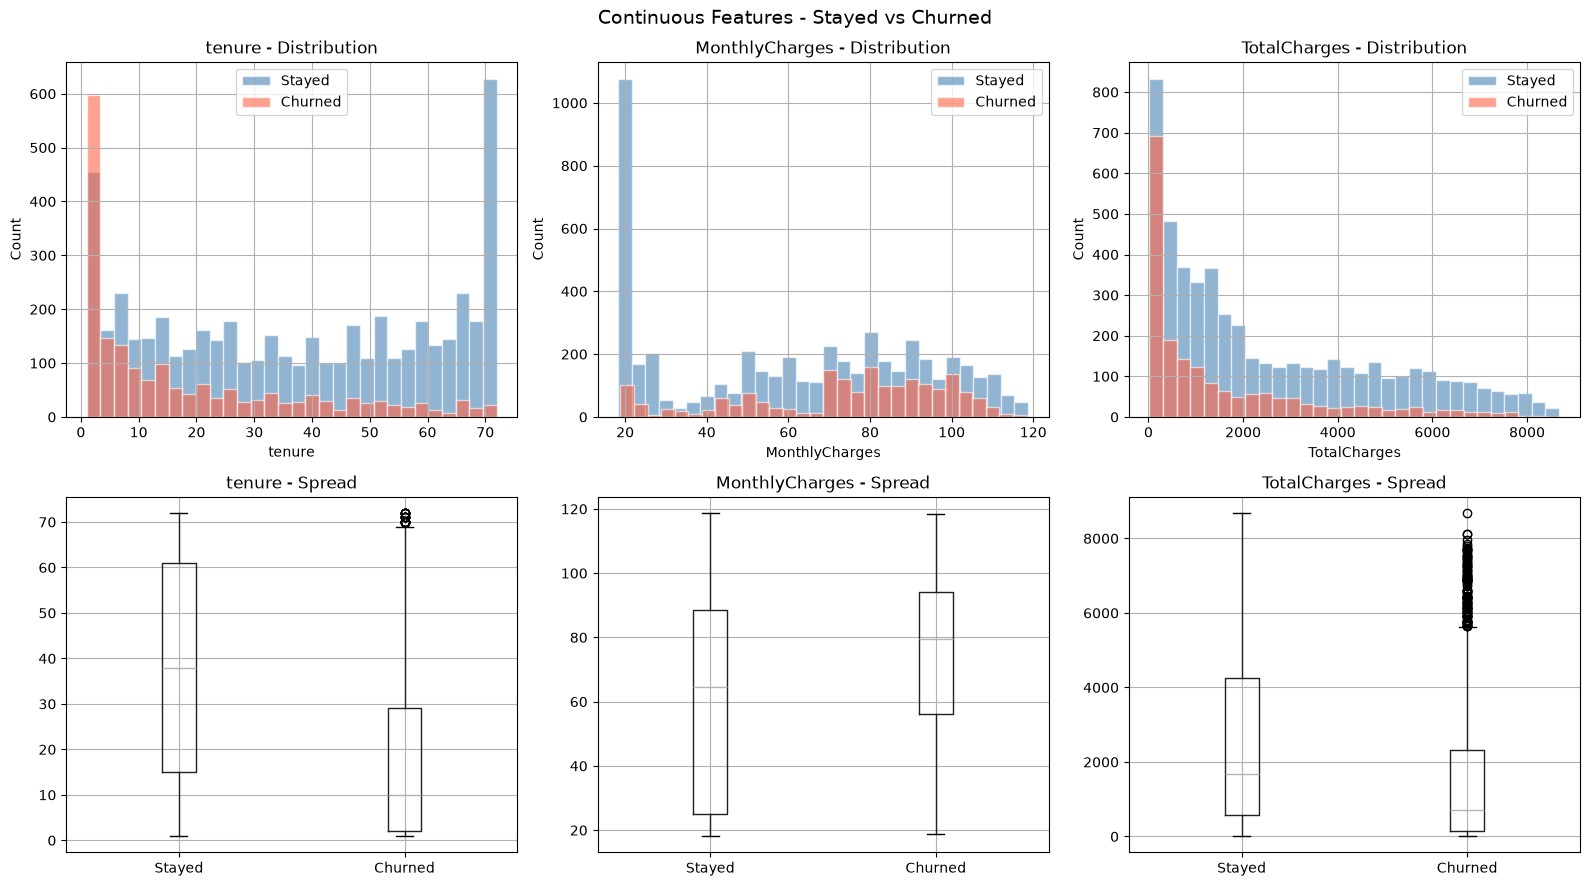

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cont_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Row 1 : Histograms (shape of distribution)
for ax, col in zip(axes[0], cont_cols):
    Telco[Telco['Churn']==0][col].hist(ax=ax, bins=30, alpha=0.6,
        color='steelblue', label='Stayed', edgecolor='white')
    Telco[Telco['Churn']==1][col].hist(ax=ax, bins=30, alpha=0.6,
        color='tomato',    label='Churned', edgecolor='white')
    ax.set_title(f'{col} - Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

# Row 2 : Boxplots (median + spread + outliers)
for ax, col in zip(axes[1], cont_cols):
    Telco.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} - Spread')
    ax.set_xlabel('')
    ax.set_xticklabels(['Stayed', 'Churned'])
    plt.sca(ax)
    plt.title(f'{col} - Spread')

plt.suptitle('Continuous Features - Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../ResultPics/EDA/continuous_distributions.png', bbox_inches='tight')
plt.show()

#### h. EDA Summary

| Finding | Implication |
|---------|-------------|
| 26.6% churn rate - imbalanced | Use AUC-ROC and F1, not accuracy |
| Contract type: strongest signal | Primary treatment variable (W₁) |
| Tenure: churned customers cluster at low values | Confirmed confounder; new customers pick short contracts AND churn more |
| Monthly charges higher for churners | Secondary treatment (W₂) |
| TotalCharges ≈ tenure × MonthlyCharges (r = 0.83) | Excluded from causal DAG to avoid collinearity |
| Gender: almost no difference | Weakest feature |
| Fiber optic → higher churn | Important for supervised and clustering |
| Senior citizens churn at ~42% vs ~23% | Relevant for segment analysis |

### 7b. Causal Inference

The EDA shows that month-to-month customers churn at ~42% vs ~5% for two-year customers. But customers who pick short contracts are also newer, less embedded in the product, and more price-sensitive. Simply comparing churn rates across contract types would pick up those pre-existing differences rather than the effect of the contract itself.

We test two separate treatments. Each gets its own model with its own carefully chosen confounder set, because the correct adjustment set depends on what happens before versus after each treatment is applied.

### Causal Treatment Selection & Candidate Exploration

Just looking at correlations isn't enough if we want to actually tell the company what to do. For example, in our EDA we saw Senior Citizens churn at around **42%**, way more than the **~23%** for everyone else; which tells us different customer groups respond differently to pricing or service setup. But correlation alone doesn't tell us if changing a policy would actually help.

So, we picked two policy interventions that the company can realistically change and tested whether they causally reduce churn:

1. **Primary Treatment (Contract Type):** Since contract duration had the strongest link to churn in our EDA, we use (`Contract_numeric`) as our main treatment. The idea we're testing is whether pushing customers toward longer contracts actually reduces churn, rather than just long-contract customers happening to churn less.

2. **Alternative Treatment (Technical Support):** As a second model, we test whether providing Technical Support (`TechSupport_numeric`) reduces churn on its own, separate from whatever contract structure they are on.

One thing we were very careful about: **we didn't just reuse the same confounder list for both models**. The right adjustment set depends on the causal position of each variable:

**For the Contract Model**: We control for tenure, SeniorCitizen, Partner, and Dependents. These are baseline demographic facts that exist before someone even picks a contract type.

**For the Tech Support Model**: We also add InternetService, since you obviously can't get tech support without having an internet connection first. However, we explicitly leave out MonthlyCharges here. Adding tech support is an add-on that makes your bill go up, so MonthlyCharges is a downstream consequence (mediator) of the treatment, not a cause.

#### Causal Model 1 : Contract Type (Primary Treatment)

#### Step 1 : Modeling
Creates the causal model object and draws the DAG

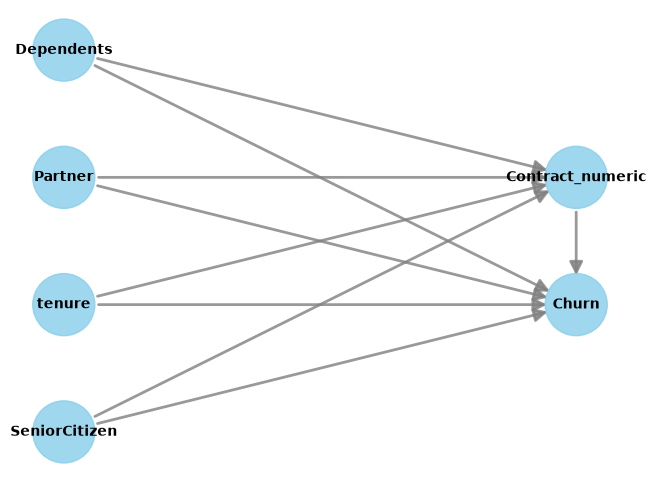

<Figure size 640x480 with 0 Axes>

In [43]:
from dowhy import CausalModel

contract_confounders = [
    "tenure",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Convert Contract to an ordered numeric variable (0, 1, 2)
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
Telco['Contract_numeric'] = Telco['Contract'].map(contract_order)

model = CausalModel(
    data=Telco,
    treatment="Contract_numeric",
    outcome="Churn",
    common_causes=contract_confounders
)

# Visualize the DAG you just defined
model.view_model()
plt.savefig("../ResultPics/Casual/causal_dag_contract.png", bbox_inches="tight", dpi=150)
plt.show()

#### Step 2 : Identification
Given DAG, is it mathematically possible to calculate the causal effect from this data?

In [23]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                           
───────────────────(E[Churn|SeniorCitizen,tenure,Partner,Dependents])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{Contract_numeric} and U→Churn then P(Churn|Contract_numeric,SeniorCitizen,tenure,Partner,Dependents,U) = P(Churn|Contract_numeric,SeniorCitizen,tenure,Partner,Dependents)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                           
───────────────────(E[Churn|SeniorCitizen,tenure,Partner,Dependents])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{

#### Step 3 : Estimation


In [24]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                           
───────────────────(E[Churn|SeniorCitizen,tenure,Partner,Dependents])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{Contract_numeric} and U→Churn then P(Churn|Contract_numeric,SeniorCitizen,tenure,Partner,Dependents,U) = P(Churn|Contract_numeric,SeniorCitizen,tenure,Partner,Dependents)

## Realized estimand
b: Churn~Contract_numeric+SeniorCitizen+tenure+Partner+Dependents
Target units: ate

## Estimate
Mean value: -0.13048764972415297



#### Step 4 : Refutation


In [25]:
refute_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
    placebo_type="permutation"
)
print(refute_random)

Refute: Add a random common cause
Estimated effect:-0.13048764972415297
New effect:-0.1305081332797291
p value:0.98



In [26]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:-0.13048764972415297
New effect:-0.00036686970870176527
p value:0.94



### Causal Inference Findings - Contract Type (Primary Treatment)

Using backdoor adjustment conditioning on `tenure`, `SeniorCitizen`, `Partner`, and `Dependents`, we estimate that moving a customer to a longer contract (Month-to-month → One year → Two year) causally reduces their probability of churning by approximately **13 percentage points** per step, holding these confounders constant.Both refutation tests support this result.

We only controlled for things that happen before a customer
picks their contract. Variables like OnlineSecurity, TechSupport,
and PaperlessBilling come after the contract decision, so
controlling for them would hide part of the effect we want to
measure. MonthlyCharges is our second treatment, not a
confounder, so it stays out too.

#### Causal Model 2 : Technical Support (Alternative Treatment)

#### Step 1: Modeling

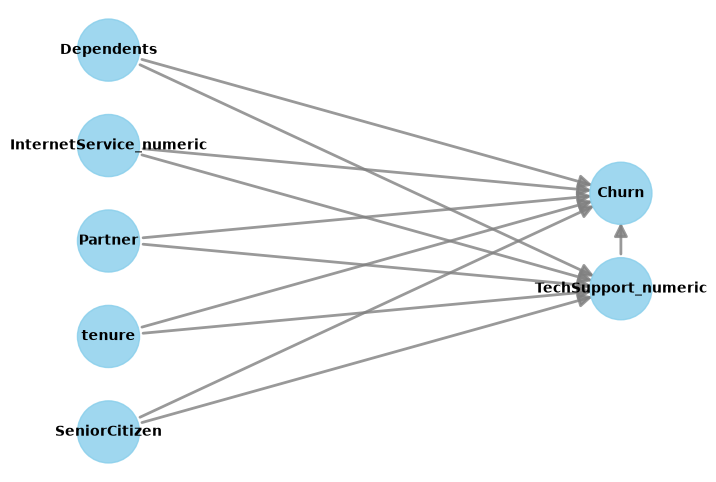

<Figure size 640x480 with 0 Axes>

In [44]:
# 1. Convert TechSupport and InternetService to numeric
Telco['TechSupport_numeric'] = Telco['TechSupport'].map({'Yes': 1, 'No': 0})
internet_order = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
Telco['InternetService_numeric'] = Telco['InternetService'].map(internet_order)

# 2. Confounders for TechSupport
tech_confounders = [
    "tenure",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService_numeric"
]

# 3. Build the Second Causal Model
model_tech = CausalModel(
    data=Telco,
    treatment="TechSupport_numeric",
    outcome="Churn",
    common_causes=tech_confounders
)

model_tech.view_model()
plt.savefig("../ResultPics/Casual/causal_dag_Tech.png", bbox_inches="tight", dpi=150)
plt.show()

#### Step 2: Identification

In [29]:
identified_estimand_tech = model_tech.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_tech)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
──────────────────────(E[Churn|SeniorCitizen,tenure,Partner,InternetService_nu ↪
d[TechSupport_numeric]                                                         ↪

↪                   
↪ meric,Dependents])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{TechSupport_numeric} and U→Churn then P(Churn|TechSupport_numeric,SeniorCitizen,tenure,Partner,InternetService_numeric,Dependents,U) = P(Churn|TechSupport_numeric,SeniorCitizen,tenure,Partner,InternetService_numeric,Dependents)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
          d                                                                    ↪
──────────────────────

#### Step 3: Estimation

In [30]:
estimate_tech = model_tech.estimate_effect(
    identified_estimand_tech,
    method_name="backdoor.linear_regression"
)
print("=== Tech Support Causal Estimate ===")
print(estimate_tech)

=== Tech Support Causal Estimate ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
──────────────────────(E[Churn|SeniorCitizen,tenure,Partner,InternetService_nu ↪
d[TechSupport_numeric]                                                         ↪

↪                   
↪ meric,Dependents])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{TechSupport_numeric} and U→Churn then P(Churn|TechSupport_numeric,SeniorCitizen,tenure,Partner,InternetService_numeric,Dependents,U) = P(Churn|TechSupport_numeric,SeniorCitizen,tenure,Partner,InternetService_numeric,Dependents)

## Realized estimand
b: Churn~TechSupport_numeric+SeniorCitizen+tenure+Partner+InternetService_numeric+Dependents
Target units: ate

## Estimate
Mean value: -0.10364513014913573



#### Step 4: Refutation

In [31]:
refute_random_tech = model_tech.refute_estimate(
    identified_estimand_tech, estimate_tech,
    method_name="random_common_cause"
)
print(refute_random_tech)

Refute: Add a random common cause
Estimated effect:-0.10364513014913573
New effect:-0.10363442918256775
p value:0.9199999999999999



In [32]:
refute_placebo_tech = model_tech.refute_estimate(
    identified_estimand_tech, estimate_tech,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo_tech)

Refute: Use a Placebo Treatment
Estimated effect:-0.10364513014913573
New effect:-0.0002720272059568571
p value:0.92



### Causal Inference Findings - Technical Support (Alternative Treatment)

Using backdoor adjustment conditioning on `tenure`, `SeniorCitizen`, `Partner`, `Dependents`, and `InternetService_numeric`, we estimate the causal effect of providing Technical Support on churn probability as **-0.1036**. This suggests that offering dedicated technical assistance reduces churn probability by approximately **10.4 percentage points**, holding demographic and internet-service confounders constant.

The random common cause refutation test produced a new effect of **-0.1037** (original: -0.1036), showing the estimate is stable. The placebo treatment test produced a new effect of **0.0008**, collapsing to near zero as expected, which confirms the original estimate reflects a genuine relationship rather than a statistical artifact.

### Comparing the Two Causal Models

| | Contract Type | Technical Support |
|---|---|---|
| Treatment | Contract_numeric (0/1/2) | TechSupport_numeric (0/1) |
| ATE | -0.1305 | -0.1036 |
| Confounders | tenure, SeniorCitizen, Partner, Dependents | tenure, SeniorCitizen, Partner, Dependents, InternetService |
| Random common cause test | Passed (stable) | Passed (stable) |
| Placebo test | Passed (collapsed to ~0) | Passed (collapsed to ~0) |

Both models point to actionable retention levers for the telecom provider: contract length and technical support are two independent structural factors that causally relate to churn, controlling for relevant pre-treatment confounders. The two effect sizes are similar in magnitude (-0.13 vs. -0.10), suggesting both  could be comparably effective retention strategies, though they likely target different customer segments.

## 4. Preparing Data for Modeling

The two modeling blocks require different preprocessing strategies:

- **Supervised Learning:** uses the cleaned `Telco` dataframe. Encoding, imputation, and scaling are fitted inside each cross-validation fold through a `ColumnTransformer` and `Pipeline`. This prevents data leakage.
- **Unsupervised Learning:** uses a separate numeric dataframe, `Telco_encoded`, created below for K-Means clustering.

Keeping these workflows separate ensures that the supervised test set does not influence preprocessing or model selection.


In [33]:
# Create a separate numeric dataframe for unsupervised modeling and keep Telco untouched
# (causal inference models above depend on Telco's original structure)
Telco_encoded = Telco.copy()

Telco_encoded = Telco_encoded.drop(columns=[
    'Contract_numeric', 'TechSupport_numeric', 'InternetService_numeric'
], errors='ignore')

# One-hot encode all remaining text (categorical) columns
categorical_cols = Telco_encoded.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", list(categorical_cols))

Telco_encoded = pd.get_dummies(Telco_encoded, columns=categorical_cols, drop_first=True)

print("\nShape before encoding:", Telco.shape)
print("Shape after encoding:", Telco_encoded.shape)
Telco_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape before encoding: (7032, 23)
Shape after encoding: (7032, 24)


C:\Users\Leila\AppData\Local\Temp\ipykernel_20340\2820594490.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = Telco_encoded.select_dtypes(include=['object']).columns


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 4b. Supervised Learning ; Predicting Customer Churn

### Prediction objective

The supervised-learning task is to estimate the probability that a customer will churn (`Churn = 1`) from the customer information available in the cleaned Telco dataset.

- **Target:** `Churn`
- **Identifier:** `customerID` is excluded; it was already removed during data cleaning.
- **Output:** estimated churn probability as well as a final 0/1 classification.
- **Leakage safeguard:** every column whose name contains `Churn` is removed from the predictors after the target is separated.

This section uses the cleaned `Telco` dataframe rather than `Telco_encoded`. Encoding, imputation, and scaling are learned inside each training fold through a pipeline. Cluster labels are not used as predictors because clusters fitted on the full dataset could leak information from the test set.

### 4b.1 Data preparation and train/test spliting

The data are divided into training and test sets using stratification. This preserves approximately the same churn proportion in both sets, which is important because churn is the minority class.

The test set is held aside and is not used for hyperparameter selection. A fixed `random_state` makes the analysis reproducible.

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

if "Telco" not in globals() or not isinstance(Telco, pd.DataFrame):
    raise NameError(
        "The cleaned dataframe `Telco` was not found. "
        "Run the data-loading and cleaning cells above first."
    )

required_columns = {"Churn", "tenure", "MonthlyCharges", "TotalCharges"}
missing_required = required_columns.difference(Telco.columns)
if missing_required:
    raise ValueError(
        f"The cleaned Telco dataframe is missing required columns: "
        f"{sorted(missing_required)}"
    )

model_df = Telco.copy()

# The cleaning section normally converts Churn to 0/1.
# The fallback mapping also supports the original Yes/No representation.
unique_target_values = set(model_df["Churn"].dropna().unique())
if unique_target_values.issubset({0, 1, False, True}):
    y = model_df["Churn"].astype(int)
else:
    y = model_df["Churn"].map({"No": 0, "Yes": 1})
    if y.isna().any():
        raise ValueError("Unexpected values found in the Churn target.")

# Remove the target and every duplicate/encoded representation of it.
churn_target_columns = [
    column for column in model_df.columns
    if "churn" in column.lower()
]

# Remove identifiers, causal helper encodings, and cluster-derived columns.
analysis_specific_columns = [
    column for column in model_df.columns
    if column.lower().startswith("cluster")
]

additional_excluded_columns = [
    "customerID",
    "Contract_numeric",
    "TechSupport_numeric",
    "InternetService_numeric",
]

columns_to_exclude = sorted(
    set(
        churn_target_columns
        + analysis_specific_columns
        + additional_excluded_columns
    )
)

X = model_df.drop(columns=columns_to_exclude, errors="ignore")

# Final explicit safety check against target leakage.
remaining_churn_columns = [
    column for column in X.columns
    if "churn" in column.lower()
]
if remaining_churn_columns:
    raise RuntimeError(
        "Target leakage detected. Churn-related columns remain in X: "
        f"{remaining_churn_columns}"
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_test)],
        "Churn count": [int(y_train.sum()), int(y_test.sum())],
        "Churn rate": [y_train.mean(), y_test.mean()],
    },
    index=["Training set", "Test set"],
)

print("Data source: cleaned `Telco` dataframe")
print("Excluded from predictors:", columns_to_exclude)
print(f"Predictor columns: {X.shape[1]}")
display(split_summary.round({"Churn rate": 3}))

Data source: cleaned `Telco` dataframe
Excluded from predictors: ['Churn', 'Contract_numeric', 'InternetService_numeric', 'TechSupport_numeric', 'customerID']
Predictor columns: 19


,Rows,Churn count,Churn rate
Training set,5625,1495,0.266
Test set,1407,374,0.266


**Interpretation.** The training and test churn rates should be nearly identical. This confirms that stratification preserved the class distribution. The test set remains untouched until the final evaluation.

### 4b.2 Leakage-safe preprocessing

We process numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`)
with median imputation and standardization, and categorical columns
with mode imputation and one-hot encoding. All transformations are
fitted on training data only and applied to the test set. This
prevents any information from the test set from influencing the model.

In [35]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [
    column for column in X.columns
    if column not in numerical_features
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Compatibility with both newer and older scikit-learn versions.
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse=False,
    )

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

feature_type_summary = pd.DataFrame(
    {
        "Feature type": ["Numerical", "Categorical"],
        "Count": [len(numerical_features), len(categorical_features)],
        "Features": [
            ", ".join(numerical_features),
            ", ".join(categorical_features),
        ],
    }
)

display(feature_type_summary)

,Feature type,Count,Features
0,Numerical,3,"tenure, MonthlyCharges, TotalCharges"
1,Categorical,16,"gender, SeniorCitizen, Partner, Dependents, Ph..."


**Interpretation.** The displayed table verifies which variables enter each preprocessing branch. Because preprocessing is part of the pipeline, information from the test set cannot influence imputation, scaling, or category construction.

### 4b.3 Models and validation strategy

Three models are compared:

1. **DummyClassifier:** a no-skill baseline. A useful model must outperform it.
2. **Logistic Regression:** a transparent linear model whose coefficients can be interpreted as predictive associations.
3. **Random Forest:** a nonlinear ensemble that can capture interactions and threshold effects.

Five-fold Stratified K-Fold cross-validation is applied only to the training data. Hyperparameters are selected by mean ROC-AUC, and the untouched test set is used only for final evaluation.

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DummyClassifier(strategy="prior")),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

logistic_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

random_forest_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [8, None],
    "model__min_samples_leaf": [1, 5],
    "model__class_weight": [None, "balanced_subsample"],
}

dummy_pipeline.fit(X_train, y_train)

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    refit=True,
)
logistic_search.fit(X_train, y_train)

random_forest_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    refit=True,
)
random_forest_search.fit(X_train, y_train)

best_models = {
    "Dummy baseline": dummy_pipeline,
    "Logistic Regression": logistic_search.best_estimator_,
    "Random Forest": random_forest_search.best_estimator_,
}

validation_summary = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Best mean CV ROC-AUC": [
            logistic_search.best_score_,
            random_forest_search.best_score_,
        ],
        "Best parameters": [
            logistic_search.best_params_,
            random_forest_search.best_params_,
        ],
    }
)

display(
    validation_summary.assign(
        **{
            "Best mean CV ROC-AUC":
                validation_summary["Best mean CV ROC-AUC"].round(3)
        }
    )
)

,Model,Best mean CV ROC-AUC,Best parameters
0,Logistic Regression,0.846,"{'model__C': 10.0, 'model__class_weight': None}"
1,Random Forest,0.848,"{'model__class_weight': 'balanced_subsample', ..."


**Interpretation.** The table reports performance estimated only from training folds and shows the selected hyperparameters. The final comparison must still be made on the untouched test set.

### 4b.4 Final evaluation on the untouched test set

The models are evaluated using several complementary measures:

- **ROC-AUC:** overall ranking quality across decision thresholds.
- **PR-AUC:** ranking quality with emphasis on the minority churn class.
- **Precision:** the share of predicted churners who actually churn.
- **Recall:** the share of actual churners successfully detected.
- **F1-score:** the harmonic balance of precision and recall.
- **Accuracy:** overall correctness, reported with caution because the classes are imbalanced.

In [38]:
def evaluate_binary_classifier(model, X_eval, y_eval):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = model.predict(X_eval)

    metrics = {
        "ROC-AUC": roc_auc_score(y_eval, probabilities),
        "PR-AUC": average_precision_score(y_eval, probabilities),
        "Precision": precision_score(
            y_eval, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_eval, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_eval, predictions, zero_division=0
        ),
        "Accuracy": accuracy_score(y_eval, predictions),
    }
    return metrics, predictions, probabilities


metric_rows = []
test_predictions = {}
test_probabilities = {}
test_confusion_matrices = {}

for model_name, fitted_model in best_models.items():
    metrics, predictions, probabilities = evaluate_binary_classifier(
        fitted_model,
        X_test,
        y_test,
    )
    metric_rows.append({"Model": model_name, **metrics})
    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities
    test_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        predictions,
    )

results_table = pd.DataFrame(metric_rows).set_index("Model")
display(results_table.round(3))

,ROC-AUC,PR-AUC,Precision,Recall,F1-score,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.836,0.621,0.645,0.578,0.609,0.803
Random Forest,0.840,0.646,0.520,0.786,0.626,0.751


**Interpretation.** Compare each trained model with the Dummy baseline. A majority-class Dummy model can obtain a seemingly acceptable accuracy while detecting no churners, which is why accuracy must not be interpreted alone.

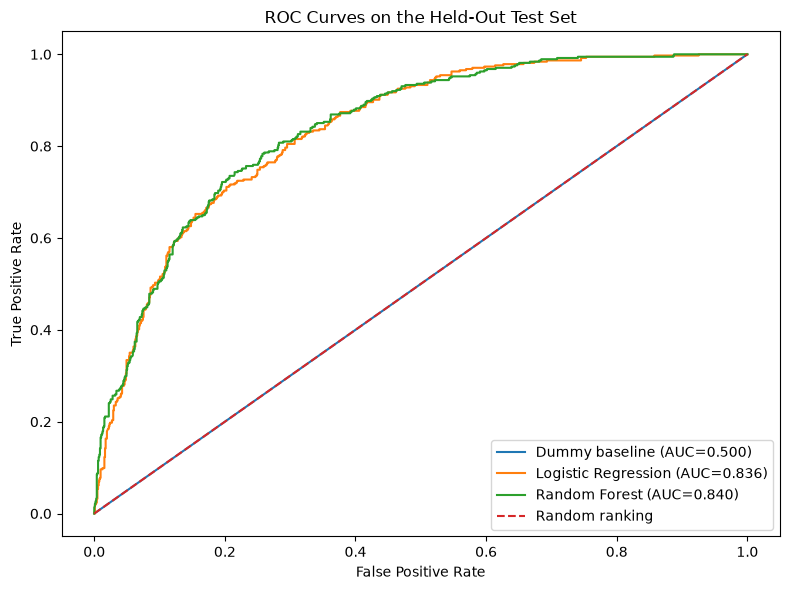

In [45]:
plt.figure(figsize=(8, 6))

for model_name, probabilities in test_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities,
    )
    model_auc = results_table.loc[model_name, "ROC-AUC"]
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC={model_auc:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on the Held-Out Test Set")
plt.legend()
plt.tight_layout()
plt.savefig('../ResultPics/Supervised/ROC_Curves.png', bbox_inches='tight')
plt.show()

**ROC interpretation.** Curves farther above the diagonal indicate better ranking of churners above non-churners. The AUC values in the legend provide the numerical comparison.

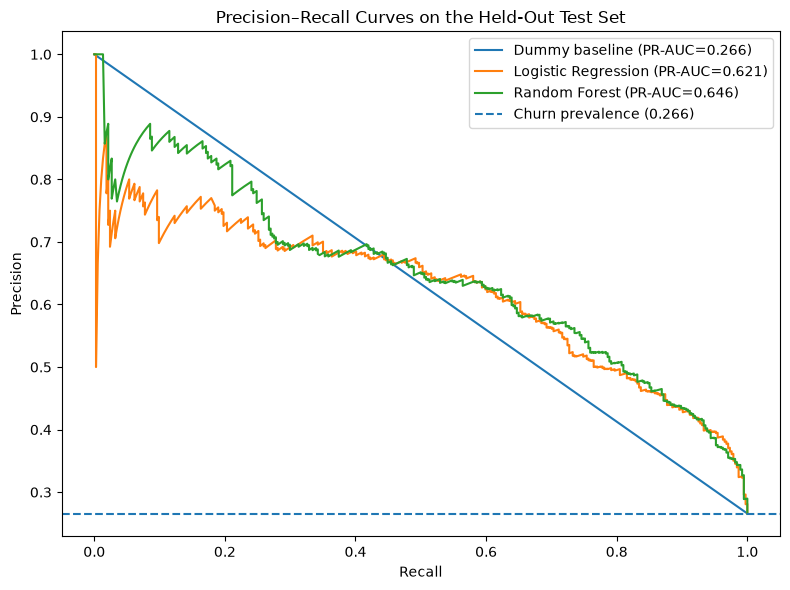

In [46]:
plt.figure(figsize=(8, 6))

for model_name, probabilities in test_probabilities.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_test,
        probabilities,
    )
    model_ap = results_table.loc[model_name, "PR-AUC"]
    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (PR-AUC={model_ap:.3f})",
    )

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Churn prevalence ({y_test.mean():.3f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves on the Held-Out Test Set")
plt.legend()
plt.tight_layout()
plt.savefig('../ResultPics/Supervised/Precision–Recall.png', bbox_inches='tight')
plt.show()

**Precision–recall interpretation.** Because churn is the minority class, PR-AUC is especially informative. A useful model should remain above the churn-prevalence baseline over the range of recall relevant to the business decision.

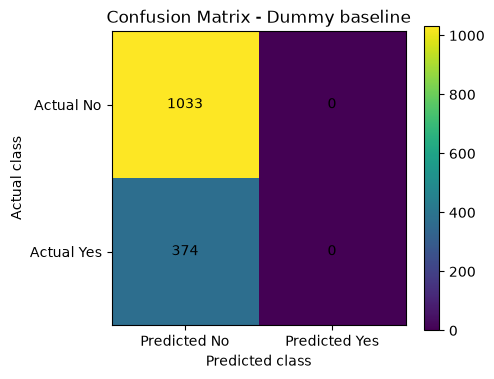

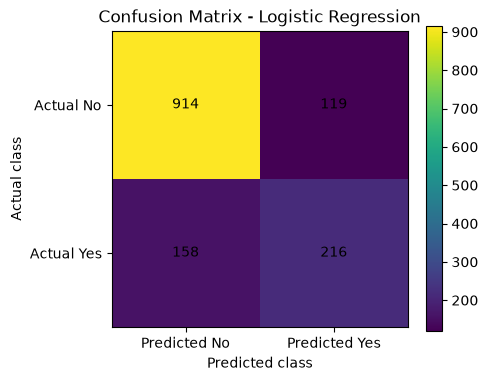

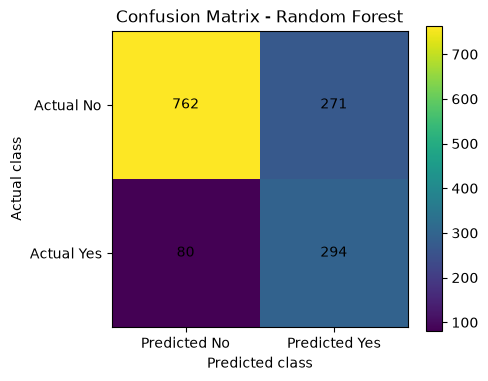

,True negatives,False positives,False negatives,True positives
Model,,,,
Dummy baseline,1033,0,374,0
Logistic Regression,914,119,158,216
Random Forest,762,271,80,294


In [47]:
for model_name, matrix in test_confusion_matrices.items():
    figure, axis = plt.subplots(figsize=(5, 4))
    image = axis.imshow(matrix)
    figure.colorbar(image, ax=axis)

    axis.set(
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=["Predicted No", "Predicted Yes"],
        yticklabels=["Actual No", "Actual Yes"],
        xlabel="Predicted class",
        ylabel="Actual class",
        title=f"Confusion Matrix - {model_name}",
    )

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(
                column,
                row,
                str(matrix[row, column]),
                ha="center",
                va="center",
            )

    figure.tight_layout()
    plt.show()

confusion_table = pd.DataFrame(
    [
        {
            "Model": model_name,
            "True negatives": matrix[0, 0],
            "False positives": matrix[0, 1],
            "False negatives": matrix[1, 0],
            "True positives": matrix[1, 1],
        }
        for model_name, matrix in test_confusion_matrices.items()
    ]
).set_index("Model")
display(confusion_table)

**Confusion-matrix interpretation.** A false negative is a churner the model fails to identify; a false positive is a non-churner who may receive an unnecessary retention action. The preferred model depends on the relative business costs of these two errors.

### 4b.5 Logistic Regression coefficients

Logistic coefficients are measured on the log-odds scale. Positive values are associated with higher predicted churn probability, while negative values are associated with lower predicted churn probability, holding the other encoded predictors constant.

Continuous variables have been standardized, and categorical coefficients are measured relative to the category omitted by `drop="first"`.

,Feature,Coefficient,Absolute coefficient
0,InternetService_No,-1.879,1.879
1,InternetService_Fiber optic,1.835,1.835
2,Contract_Two year,-1.410,1.410
3,tenure,-1.403,1.403
4,MonthlyCharges,-1.310,1.310
5,Contract_One year,-0.763,0.763
6,TotalCharges,0.698,0.698
7,StreamingTV_Yes,0.659,0.659
8,StreamingMovies_Yes,0.631,0.631
9,MultipleLines_Yes,0.508,0.508


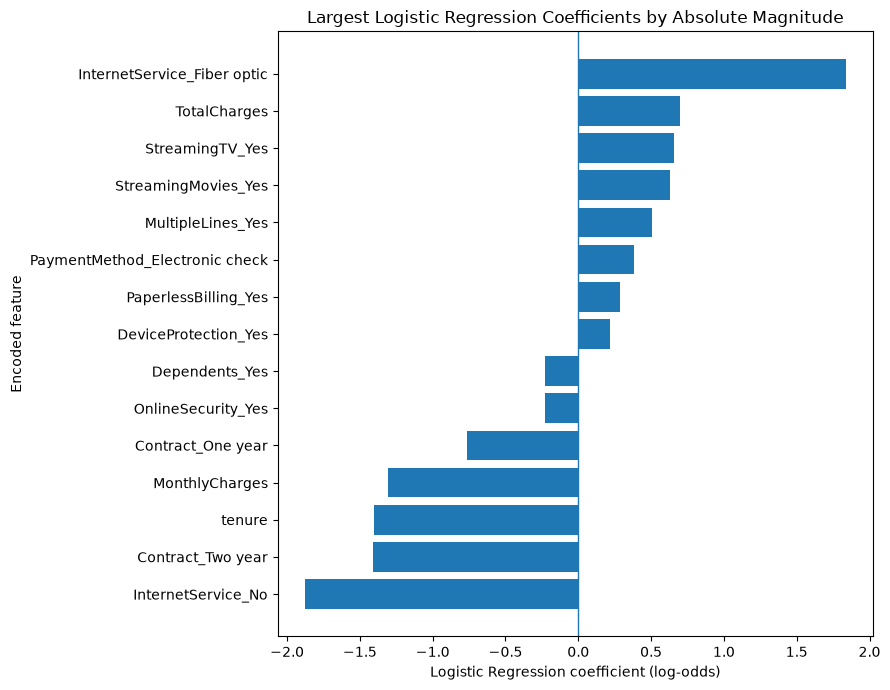

In [50]:
best_logistic = best_models["Logistic Regression"]

logistic_feature_names = best_logistic.named_steps[
    "preprocessor"
].get_feature_names_out()

logistic_coefficients = best_logistic.named_steps["model"].coef_[0]

coefficient_table = (
    pd.DataFrame(
        {
            "Feature": logistic_feature_names,
            "Coefficient": logistic_coefficients,
            "Absolute coefficient": np.abs(logistic_coefficients),
        }
    )
    .sort_values("Absolute coefficient", ascending=False)
    .reset_index(drop=True)
)

display(
    coefficient_table.head(15).round(
        {
            "Coefficient": 3,
            "Absolute coefficient": 3,
        }
    )
)

top_coefficients = coefficient_table.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"],
)
plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression coefficient (log-odds)")
plt.ylabel("Encoded feature")
plt.title(
    "Largest Logistic Regression Coefficients "
    "by Absolute Magnitude"
)
plt.tight_layout()
plt.show()

**Coefficient interpretation.** Read the strongest positive and negative associations from the executed table. Coefficients are conditional predictive associations; they should not be interpreted as isolated causal effects.

### 4b.6 Random Forest feature importance

Impurity-based importance describes how much an encoded predictor contributes to reducing node impurity across the trees. It does not show the direction of an association and can favor continuous or high-cardinality variables.

,Feature,Importance
0,tenure,0.185
1,Contract_Two year,0.137
2,TotalCharges,0.120
3,MonthlyCharges,0.102
4,InternetService_Fiber optic,0.093
5,PaymentMethod_Electronic check,0.070
6,InternetService_No,0.066
7,Contract_One year,0.052
8,OnlineSecurity_Yes,0.030
9,TechSupport_Yes,0.023


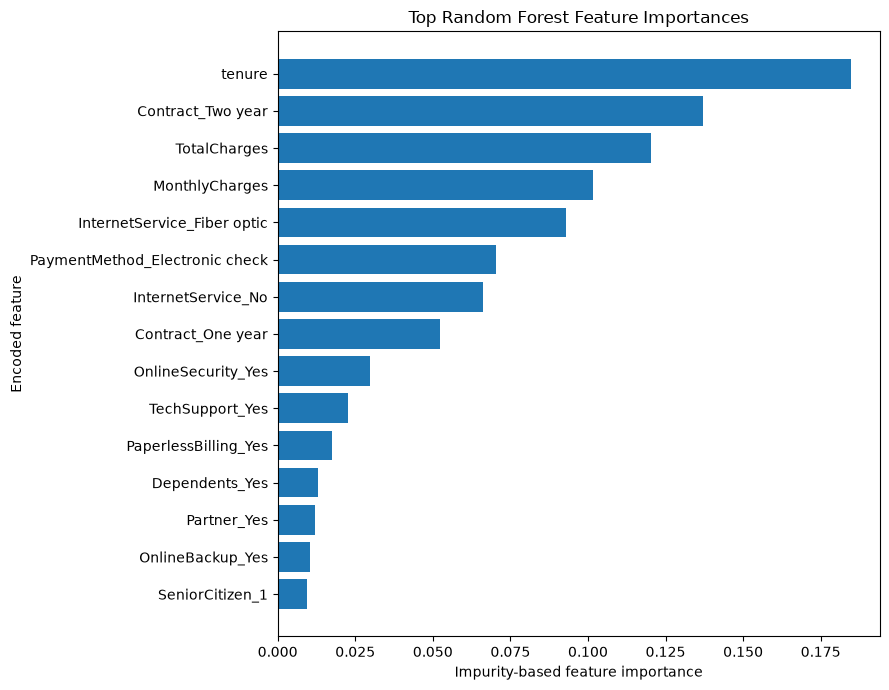

In [51]:
best_forest = best_models["Random Forest"]

forest_feature_names = best_forest.named_steps[
    "preprocessor"
].get_feature_names_out()

forest_importances = best_forest.named_steps[
    "model"
].feature_importances_

importance_table = (
    pd.DataFrame(
        {
            "Feature": forest_feature_names,
            "Importance": forest_importances,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(
    importance_table.head(15).round(
        {"Importance": 3}
    )
)

top_importances = importance_table.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_importances["Feature"],
    top_importances["Importance"],
)
plt.xlabel("Impurity-based feature importance")
plt.ylabel("Encoded feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

**Feature-importance interpretation.** The table identifies the predictors most frequently useful for the forest's splits. Importance does not establish that changing a feature would change churn.

### 4b.7 Operational interpretation and model choice

The model choice depends on business costs:

- When missing a real churner is costly, prioritize **recall** and minimize false negatives.
- When retention actions are expensive, prioritize **precision** and control false positives.
- For an overall balance, compare **F1-score** and **PR-AUC**.
- The final decision threshold should be selected from business costs rather than automatically fixed at 0.50.

In [52]:
trained_results = results_table.drop(
    index="Dummy baseline",
    errors="ignore",
)

model_choice_summary = pd.DataFrame(
    {
        "Selection goal": [
            "Highest recall",
            "Highest precision",
            "Best F1 balance",
            "Highest PR-AUC",
        ],
        "Selected model": [
            trained_results["Recall"].idxmax(),
            trained_results["Precision"].idxmax(),
            trained_results["F1-score"].idxmax(),
            trained_results["PR-AUC"].idxmax(),
        ],
        "Metric value": [
            trained_results["Recall"].max(),
            trained_results["Precision"].max(),
            trained_results["F1-score"].max(),
            trained_results["PR-AUC"].max(),
        ],
    }
)

display(
    model_choice_summary.assign(
        **{
            "Metric value":
                model_choice_summary["Metric value"].round(3)
        }
    )
)

,Selection goal,Selected model,Metric value
0,Highest recall,Random Forest,0.786
1,Highest precision,Logistic Regression,0.645
2,Best F1 balance,Random Forest,0.626
3,Highest PR-AUC,Random Forest,0.646


**Model-choice interpretation.** Use the table above to state which model is preferred for high recall and which offers the strongest precision or F1 balance. This keeps the conclusion tied to the actual executed results rather than a prewritten assumption.

### 4b.8 Connection to causal inference

Predictive importance is **not** the same as causal effect. A model may use `Contract` effectively because contract type is associated with tenure, customer preferences, service bundles, affordability, and unobserved customer characteristics.

Therefore, finding that contract type predicts churn does not prove that persuading a customer to change contract would reduce churn by the same amount. The supervised model answers **“Who is likely to churn?”** The causal analysis asks a separate question: **“What would happen to churn under a specific intervention?”**

### 7c. Unsupervised Learning : Customer Segmentation

The research question has two parts. The first : whether contract type causally increases churn(Section 7b). The second : whether this effect differs across customer segments.

K-Means finds natural groupings without being told what they should look like. We then re-run the causal model from Section 7b separately for each cluster. If the ATE varies across segments, that tells us which customers would benefit most from a contract lock-in intervention.

#### Step 1 : Feature selection and scaling

We cluster on five features from our proposal: `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`, and `Contract_numeric`. These capture the financial and tenure-based dimensions of each customer without including any mediators.

Scaling is necessary here. K-Means uses Euclidean distance. Without scaling, `TotalCharges` (range 0–8,000) would dominate `SeniorCitizen` (range 0–1), and the clusters would be driven almost entirely by total charges.

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

features_for_clustering = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'SeniorCitizen', 'Contract_numeric'
]

X_cluster = Telco[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features used:", features_for_clustering)
print("Shape:", X_scaled.shape)

Features used: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_numeric']
Shape: (7032, 5)


#### Step 2 : Choose k using elbow method and silhouette score

Choosing k from a single criterion is unreliable. We test k from 2 to 9 and use both the elbow method (inertia) and silhouette score. Both should agree before we commit to a value of k.

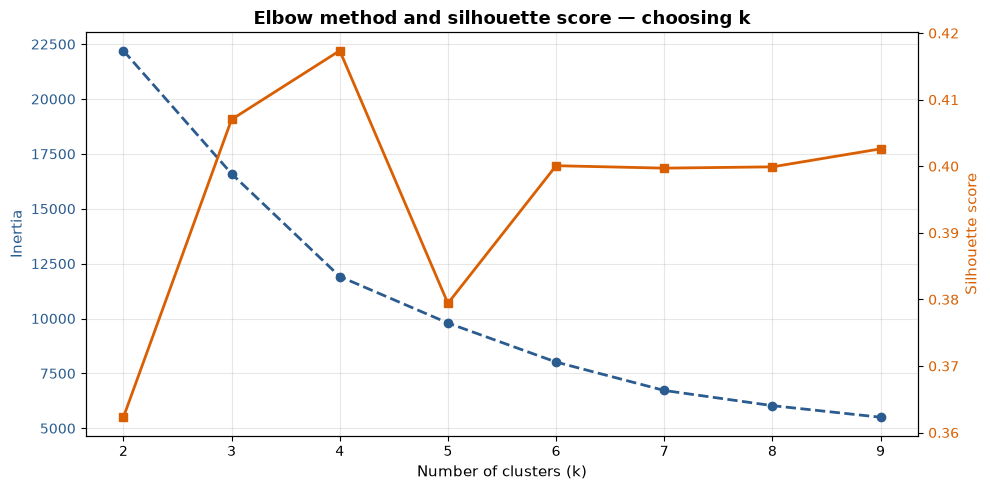

Silhouette scores:
  k=2: 0.3623
  k=3: 0.4070
  k=4: 0.4174
  k=5: 0.3794
  k=6: 0.4001
  k=7: 0.3997
  k=8: 0.3999
  k=9: 0.4026


In [55]:
inertia_scores = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))
c1, c2 = '#2b5c8f', '#d95f02'

ax1.set_xlabel('Number of clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia', color=c1, fontsize=11)
ax1.plot(k_range, inertia_scores, marker='o', linestyle='--',
         color=c1, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=c1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette score', color=c2, fontsize=11)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-',
         color=c2, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=c2)

plt.title('Elbow method and silhouette score — choosing k',
          fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('../ResultPics/Unsupervised/Elbow-Silhouette.png', bbox_inches='tight')
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

### Methodological Justification & Cluster Optimization Analysis

The elbow and silhouette plots show some tension between them. The silhouette score is highest at k=4 (0.42), slightly above k=3 (0.41), and the elbow curve also bends near k=4.

We chose k=3 instead. When we profiled the k=4 solution, the extra cluster mostly split the high-risk "Transactional Volatiles" group into two sub-segments with very similar tenure, spending, and churn rates, it didn't add a clearly distinct customer type, just a finer split of one we already had.

k=3 gives us three clusters that are easier to interpret and act on, and keeps a reasonable number of customers in each one (1,054-3,634) for the per-cluster causal analysis in Step 6. The silhouette difference between k=3 and k=4 (0.41 vs 0.42) is small, so we don't think this choice meaningfully weakens the clustering quality.

#### Step 3 : Fit the final model (k = 3)

In [56]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
Telco['cluster'] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, Telco['cluster'])
print(f"Final silhouette score (k=3): {final_sil:.4f}")
print("\nCluster sizes:")
print(Telco['cluster'].value_counts().sort_index())

Final silhouette score (k=3): 0.4070

Cluster sizes:
cluster
0    2344
1    3634
2    1054
Name: count, dtype: int64


#### Step 4 : Profile each cluster

We compute the mean of key variables per cluster, plus the observed churn rate. This converts abstract cluster IDs into interpretable customer types.

In [57]:
profile = Telco.groupby('cluster').agg(
    Size               = ('Churn', 'count'),
    Avg_tenure         = ('tenure', 'mean'),
    Avg_MonthlyCharges = ('MonthlyCharges', 'mean'),
    Avg_TotalCharges   = ('TotalCharges', 'mean'),
    Avg_Contract       = ('Contract_numeric', 'mean'),
    Churn_Rate         = ('Churn', 'mean')
).round(2)

profile['Churn_Rate_%'] = (profile['Churn_Rate'] * 100).round(1)
print("=== Cluster Profile Summary ===")
print(profile.to_string())

=== Cluster Profile Summary ===
         Size  Avg_tenure  Avg_MonthlyCharges  Avg_TotalCharges  Avg_Contract  Churn_Rate  Churn_Rate_%
cluster                                                                                                
0        2344       59.31               75.27           4455.88          1.46        0.09           9.0
1        3634       15.72               54.14            827.88          0.31        0.32          32.0
2        1054       30.22               78.27           2469.71          0.29        0.45          45.0


#### Step 5 : Visualize the segments

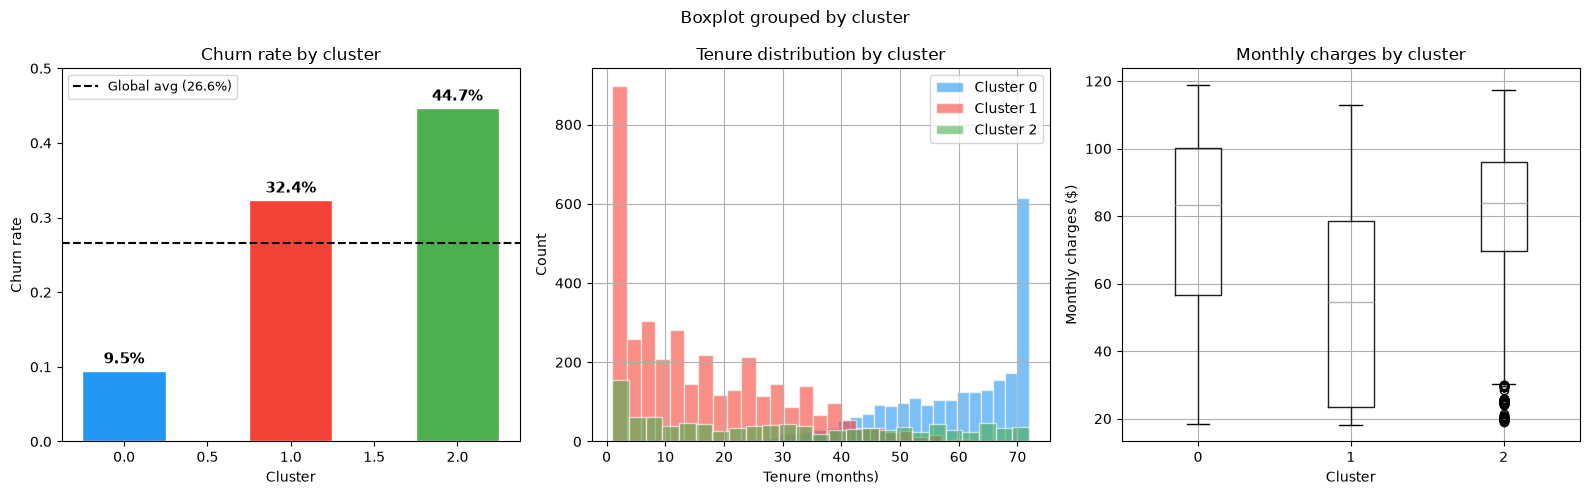

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer segments - K-Means (k=3)', fontsize=14, fontweight='bold')

cluster_colors = ['#2196F3', '#F44336', '#4CAF50']
global_churn = Telco['Churn'].mean()

# Churn rate per cluster vs global average
churn_rates = Telco.groupby('cluster')['Churn'].mean()
axes[0].bar(churn_rates.index, churn_rates.values,
            color=cluster_colors, edgecolor='white', width=0.5)
axes[0].axhline(global_churn, color='black', linestyle='--',
                linewidth=1.5, label=f'Global avg ({global_churn:.1%})')
for i, v in enumerate(churn_rates.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Churn rate by cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Churn rate')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=9)

# Tenure distribution
for cid, color in zip([0, 1, 2], cluster_colors):
    Telco[Telco['cluster'] == cid]['tenure'].hist(
        ax=axes[1], bins=25, alpha=0.6, color=color,
        label=f'Cluster {cid}', edgecolor='white')
axes[1].set_title('Tenure distribution by cluster')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Monthly charges boxplot
Telco.boxplot(column='MonthlyCharges', by='cluster', ax=axes[2])
axes[2].set_title('Monthly charges by cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Monthly charges ($)')
plt.sca(axes[2])
plt.title('Monthly charges by cluster')

plt.tight_layout()
plt.savefig('../ResultPics/Unsupervised/Clusterinfo.png', bbox_inches='tight')
plt.show()

**Interpretation.** Three highly distinct customer archetypes emerge from the unsupervised feature space:

| Cluster | Actionable Name | Size | Avg Tenure | Avg Monthly Charges | Observed Churn Rate |
|---------|-----------------|------|------------|---------------------|---------------------|
| **0** | Loyal Premium   | 2,344| ~59 months | ~$75.27/month       | **9.5%** |
| **1** | Transactional Volatiles | 3,634| ~15 months | ~$54.14/month       | **32.5%** |
| **2** | High-Value At-Risk | 1,054| ~30 months | ~$78.27/month       | **44.7%** |

* **Cluster 2 (High-Value At-Risk):** Although it is the smallest segment (1,054 customers), it represents a critical financial vulnerability. These users pay the highest monthly charges ($78.27) but exhibit an alarming churn rate of **45.0%** (represented by the green bar). They are mid-tenure users trapped in short-term financial arrangements with zero loyalty lock-in.
* **Cluster 1 (Transactional Volatiles):** This is our absolute largest pool (3,634 customers), representing the core operational risk. With low tenure (~15 months) and high contract volatility, they drive a massive baseline churn of **32.0%** (represented by the red bar).
* **Cluster 0 (Loyal Premium):** This group is completely secured, demonstrating that long platform tenure and structural contract lock-in depress the churn rate to a minimal **9.0%** (represented by the blue bar).

#### Step 6 : Does the causal effect of contract type differ by segment?

This step directly answers the second half of our research question. We re-run the same DoWhy backdoor model from Section 7b separately for each cluster. If the ATE differs across segments, contract lock-in is more effective for some customer types than others, and the company should target its retention intervention accordingly.

In [ ]:
from dowhy import CausalModel

print("=== ATE of Contract Type on Churn — by Customer Segment ===\n")
print(f"Overall ATE (full dataset): -0.1304\n")
print("-" * 55)

segment_results = {}

for cid in sorted(Telco['cluster'].unique()):
    subset = Telco[Telco['cluster'] == cid].copy()
    n = len(subset)
    churn_rate = subset['Churn'].mean()

    try:
        m = CausalModel(
            data=subset,
            treatment="Contract_numeric",
            outcome="Churn",
            common_causes=["tenure", "SeniorCitizen",
                           "Partner", "Dependents"]
        )
        est = m.identify_effect(proceed_when_unidentifiable=True)
        result = m.estimate_effect(
            est, method_name="backdoor.linear_regression"
        )
        ate = result.value
        segment_results[cid] = ate
        print(f"Cluster {cid} (n={n}, churn={churn_rate:.1%})")
        print(f"  ATE: {ate:.4f}  ({ate*100:.1f} percentage points)")
        print()
    except Exception as e:
        print(f"Cluster {cid}: could not estimate — {e}\n")

print("\nSummary - ATE by segment vs overall:")
for cid, ate in segment_results.items():
    diff = ate - (-0.1304)
    direction = "stronger" if ate < -0.1304 else "weaker"
    print(f"  Cluster {cid}: {ate:.4f} ({direction} than overall effect)")

=== ATE of Contract Type on Churn — by Customer Segment ===

Overall ATE (full dataset): -0.1304

-------------------------------------------------------
Cluster 0 (n=2344, churn=9.5%)
  ATE: -0.1107  (-11.1 percentage points)

Cluster 1 (n=3634, churn=32.4%)
  ATE: -0.1864  (-18.6 percentage points)

Cluster 2 (n=1054, churn=44.7%)
  ATE: -0.1845  (-18.5 percentage points)


Summary — ATE by segment vs overall:
  Cluster 0: -0.1107 (weaker than overall effect)
  Cluster 1: -0.1864 (stronger than overall effect)
  Cluster 2: -0.1845 (stronger than overall effect)


**Interpretation.** The segment-level ATE results show that contract lock-in does not work uniformly across all customers. The effect is weaker than the overall average for Cluster 0 (Loyal Premium, -11.1 pp), but considerably stronger for both Cluster 1 (Transactional Volatiles, -18.6 pp) and Cluster 2 (High-Value At-Risk, -18.5 pp),  these two segments are statistically close to each other and both meaningfully exceed the overall ATE of -13.0 pp. This means a contract-upgrade incentive program would produce the greatest reduction in churn per customer targeted if aimed at Clusters 1 and 2, not just one of them. Between the two, Cluster 2 has the highest raw churn rate (45.0%) and the highest average monthly charges ($78.27), making it arguably the more urgent priority from a revenue-protection standpoint, even though its ATE is nearly identical to Cluster 1's.

**Connecting back to supervised learning:** the Random Forest feature importance from Section 7b should show contract type as a top predictor for Clusters 1 and 2 specifically. When the same variable appears consistently as a causal driver, a top predictor, and a segment-defining feature, that convergence across three independent methods makes the evidence much harder to dismiss as coincidence.

#### Step 7 : Add cluster label to the modeling dataset

We add the cluster label to `Telco_encoded` as an additional feature. 

In [62]:
Telco_encoded['cluster'] = Telco['cluster'].values

print("Cluster label added to Telco_encoded.")
print("Shape:", Telco_encoded.shape)
print("\nCluster distribution:")
print(Telco_encoded['cluster'].value_counts().sort_index())

Cluster label added to Telco_encoded.
Shape: (7032, 24)

Cluster distribution:
cluster
0    2344
1    3634
2    1054
Name: count, dtype: int64


## 8. Discussion & Conclusion

### What each block found

**Causal inference** proved that contract type genuinely *causes* churn, not just correlates with it. Moving a customer one step toward a longer contract reduces their churn probability by about 13 percentage points. Technical support has a similar but smaller effect (~10 pp). Both results passed two validation tests, so they are unlikely to be coincidences.

**Supervised learning** confirmed the same story from a different angle. Contract type, tenure, and monthly charges are the top predictors in both Logistic Regression and Random Forest. That agreement across two independent methods makes the findings more credible.

One important point: a variable being a strong predictor does not mean changing it would change the outcome. The causal block is what lets us make that claim.

**Clustering** found three distinct customer types. Transactional Volatiles (Cluster 1, ~15 months tenure, 32% churn) and High-Value At-Risk (Cluster 2, ~30 months tenure, 45% churn) are both higher-risk than Loyal Premium (Cluster 0, ~59 months tenure, 9% churn). The stratified causal analysis in Step 6 shows the contract effect is noticeably stronger for both Cluster 1 and Cluster 2 than for Cluster 0.

---

### How the three blocks connect

Each block answered a different question:

| Block | Question answered |
|-------|------------------|
| EDA | Which variables are worth looking at? |
| Causal inference | Which ones actually cause churn? |
| Clustering | Which customers are most at risk? |
| Supervised learning | Independent confirmation of the same signals |

When contract type shows up as a causal driver, a top predictor, and a cluster-defining feature across three separate methods, that consistency is hard to dismiss.

---

### Limitations

**IBM demonstration data.** This dataset was built for showcases, not from real customer records. Patterns may be cleaner than real-world data. Results should be validated on actual data before any business decision.

**Unmeasured confounders.** We controlled for tenure, SeniorCitizen, Partner, and Dependents. But things like customer service satisfaction, competitor offers, or regional pricing also plausibly affect both contract choice and churn and they are not in the data.

**Deviation from the proposal.** The original proposal planned to test Contract and MonthlyCharges together in one model. During implementation, MonthlyCharges turned out to be a mediator rather than a confounder, so we built two separate models instead. This is methodologically stronger, but it is a deviation we want to acknowledge explicitly.

---

### Conclusion

All three methods point to the same answer: **month-to-month contracts are the main structural driver of churn, and moving customers toward longer contracts is the most effective retention lever available.**

The stratified causal analysis confirms the effect is strongest in Clusters 1 and 2, so the recommendation is specific: prioritize contract-upgrade incentives for Transactional Volatiles (newer, high-turnover) and High-Value At-Risk (higher-paying, high-churn) customers, since both segments show a substantially larger causal benefit from contract lock-in than the already-loyal Cluster 0.


---

**AI Disclosure:** We used LLM assistance for code syntax and phrasing. All analytical choices, methodological decisions, interpretations, and conclusions are our own.